In [37]:
import csv 
import os 
import pandas as pd
import matplotlib.pyplot as plt

## POC First model: Trends in Hospital Discharges as ir relates to reproductive system disorders 



Ultimately we wanted to see if the inpatient hospital charges for medicare had significant trends in the number of the discharges as it relates to reproductive system disorders for women. This specific data is for medicare part A (Mandatory), ultimately since the data isn't updated quaterly there wasn't enough in just these years to be able to build a model that we were hoping to build with the first model. For the second iteration we might pivot more to building a model of how medicare services that are covered specifically relating to female reproductive health disorders may play a role in these numbers, or see if these is data beyond 2013 to be able to do a better time series analysis on these trends. It does not appear to have a storng cut-off for the ACF plot. 

Dataset: https://data.cms.gov/provider-summary-by-type-of-service/medicare-inpatient-hospitals/medicare-inpatient-hospitals-by-geography-and-service

citation: Centers for Medicare & Medicaid Services. Medicare Inpatient Hospitals - by Geography and Service. Centers for Medicare & Medicaid Services. Published May 14, 2025; last modified May 22, 2025. Dataset. https://data.cms.gov/provider-summary-by-type-of-service/medicare-inpatient-hospitals/medicare-inpatient-hospitals-by-geography-and-service



Documenation citations: Python Software Foundation. os — Miscellaneous operating system interfaces. Python Software Foundation. Last modified Mar 13, 2026. https://docs.python.org/3/library/os.html

Text(0.5, 1.0, 'Initial Plot')

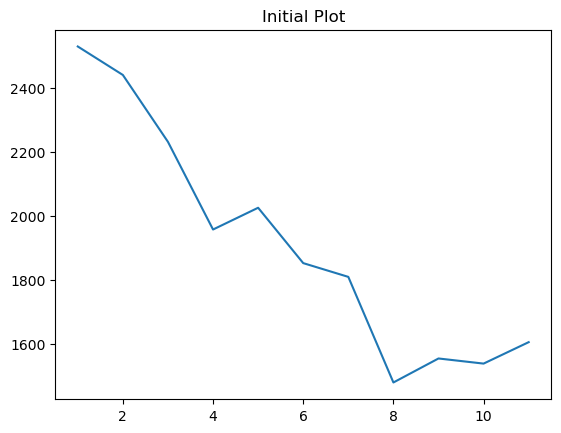

In [58]:


year = []

measurement = []



iterator = 0 

for file in os.listdir("ds4420data"): 
    iterator += 1 
    measure = 0
    current_df = pd.read_csv(file)
    year.append(iterator)
    current_df = current_df[current_df["Rndrng_Prvdr_Geo_Lvl"] == "National"]
    current_df = current_df[current_df["DRG_Desc"].isin(["MENSTRUAL AND OTHER FEMALE REPRODUCTIVE SYSTEM DISORDERS WITH CC/MCC","MENSTRUAL AND OTHER FEMALE REPRODUCTIVE SYSTEM DISORDERS WITHOUT CC/MCC"])]
    for i in current_df["Tot_Dschrgs"]: 
        measure += i 
    measurement.append(measure)
    
plt.plot(year, measurement)
plt.title("Initial Plot")

#  'MENSTRUAL AND OTHER FEMALE REPRODUCTIVE SYSTEM DISORDERS WITH CC/MCC',
  #     'MENSTRUAL AND OTHER FEMALE REPRODUCTIVE SYSTEM DISORDERS WITHOUT CC/MCC"

In [53]:
df_restructured = pd.DataFrame(measurement, year)

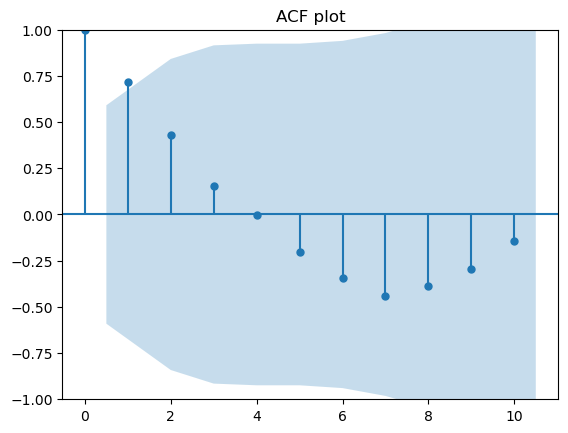

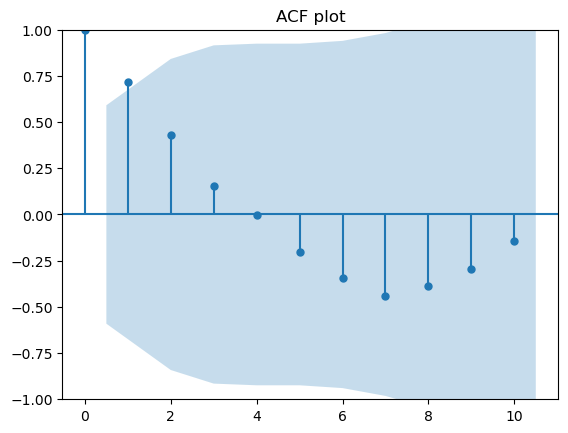

In [57]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_restructured[0], title = "ACF plot")